In [3]:
import pandas as pd
import plotly.express as px

In [9]:
df = pd.read_csv('SEI01 - Energy Balance Ireland.csv')
df.head()

,STATISTIC,Statistic Label,C02405V02899,Energy Supply and Consumption,TLIST(A1),Year,C02404V02898,Fuel Type,UNIT,VALUE
0,SEI01,Energy Balance,1,Indigenous production,1990,1990,01,Sum of all coal products,ktoe,16
1,SEI01,Energy Balance,1,Indigenous production,1990,1990,0101,Bituminous coal,ktoe,16
2,SEI01,Energy Balance,1,Indigenous production,1990,1990,0102,Anthracite and manufactured ovoids,ktoe,0
3,SEI01,Energy Balance,1,Indigenous production,1990,1990,0103,Coke,ktoe,0
4,SEI01,Energy Balance,1,Indigenous production,1990,1990,0104,Lignite,ktoe,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110704 entries, 0 to 110703
Data columns (total 10 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   STATISTIC                      110704 non-null  object
 1   Statistic Label                110704 non-null  object
 2   C02405V02899                   110704 non-null  int64 
 3   Energy Supply and Consumption  110704 non-null  object
 4   TLIST(A1)                      110704 non-null  int64 
 5   Year                           110704 non-null  int64 
 6   C02404V02898                   110704 non-null  object
 7   Fuel Type                      110704 non-null  object
 8   UNIT                           110704 non-null  object
 9   VALUE                          110704 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 8.4+ MB


In [14]:
try:
    df = df.iloc[:, [3, 5, 7, 8, 9]]
except:
    print('No changes made.')


In [41]:
df['Energy Supply and Consumption'].unique()

array(['Indigenous production', 'Imports', 'Exports', 'Mar. bunkers',
       'Stock change', 'Primary energy supply including non energy',
       'Primary energy requirement excluding non energy',
       'Sum of all transformation input',
       'Transformation input- public thermal power plants',
       'Transformation input- combined heat and power plants',
       'Transformation input- pumped storage consumption',
       'Transformation input- briquetting plants',
       'Transformation input- oil refineries and other energy sectors',
       'Sum of all transformation output',
       'Transformation output- public thermal power plants',
       'Transformation output- combined heat and power plants- electricity',
       'Transformation output- combined heat and power plants- heat',
       'Transformation output- pumped storage consumption',
       'Transformation output- briquetting plants',
       'Transformation output- oil refineries',
       'Sum of all exchanges and transfers',


In [18]:
import_exports_df=df.loc[(df['Energy Supply and Consumption'] == 'Imports') | (df['Energy Supply and Consumption'] == 'Exports') ]
import_exports_df.head()

,Energy Supply and Consumption,Year,Fuel Type,UNIT,VALUE
1496,Imports,1990,Sum of all coal products,ktoe,2010
1497,Imports,1990,Bituminous coal,ktoe,1991
1498,Imports,1990,Anthracite and manufactured ovoids,ktoe,0
1499,Imports,1990,Coke,ktoe,0
1500,Imports,1990,Lignite,ktoe,19


In [20]:
import_exports_df=import_exports_df[import_exports_df['Fuel Type'].str.contains('Sum', na=False)]
import_exports_df

,Energy Supply and Consumption,Year,Fuel Type,UNIT,VALUE
1496,Imports,1990,Sum of all coal products,ktoe,2010
1501,Imports,1990,Sum of all peat products,ktoe,0
1505,Imports,1990,Sum of all petroleum products,ktoe,5803
1521,Imports,1990,Sum of all renewable energies,ktoe,0
1538,Imports,1990,Sum of all fuel products,ktoe,7813
...,...,...,...,...,...
4444,Exports,2023,Sum of all coal products,ktoe,34
4449,Exports,2023,Sum of all peat products,ktoe,0
4453,Exports,2023,Sum of all petroleum products,ktoe,1363
4469,Exports,2023,Sum of all renewable energies,ktoe,16


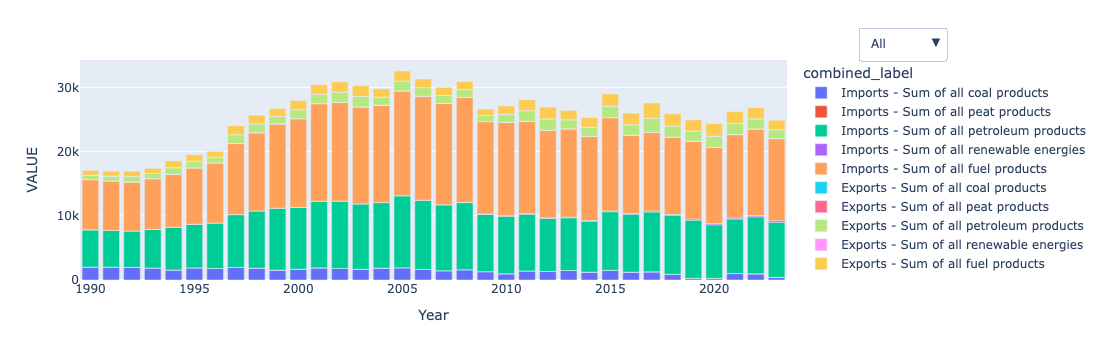

In [85]:
import_exports_df['combined_label'] = (
    import_exports_df['Energy Supply and Consumption'] + ' - ' + import_exports_df['Fuel Type']
)

fig = px.bar(
    import_exports_df,
    x='Year',
    y='VALUE',
    color='combined_label'  # Now using the combined column
)

# Get unique import/export categories
import_labels = import_exports_df[import_exports_df['Energy Supply and Consumption'] == 'Imports']['combined_label'].unique()
export_labels = import_exports_df[import_exports_df['Energy Supply and Consumption'] == 'Exports']['combined_label'].unique()

# Update layout with dropdown
fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=list([
                dict(label="All",
                     method="update",
                     args=[{"visible": [True] * len(fig.data)},
                           {"title": "All"}]),

                dict(label="Imports",
                     method="update",
                     args=[{
                         "visible": [trace.name in import_labels for trace in fig.data]
                     },
                     {"title": "Imports Only"}]),

                dict(label="Exports",
                     method="update",
                     args=[{
                         "visible": [trace.name in export_labels for trace in fig.data]
                     },
                     {"title": "Exports Only"}]),
            ]),
            direction="down",
            showactive=True,
            x=1.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        ),
    ]
)


fig.show()

In [65]:
df2= pd.read_csv('estat_sdg_07_11_en.csv')
df2.head()

,DATAFLOW,LAST UPDATE,freq,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2005,100.0,NaN,NaN
1,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2006,100.3,NaN,NaN
2,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2007,98.7,NaN,NaN
3,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2008,98.8,NaN,NaN
4,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2009,95.7,NaN,NaN


In [67]:
df.shape

(110704, 5)

In [69]:
df2.isnull().sum()

DATAFLOW          0
LAST UPDATE       0
freq              0
unit              0
geo               0
TIME_PERIOD       0
OBS_VALUE         0
OBS_FLAG       1554
CONF_STATUS    1596
dtype: int64

In [71]:
df2.drop(columns=['DATAFLOW', 'LAST UPDATE', 'freq', 'OBS_FLAG', 'CONF_STATUS'], inplace=True)
df2

,unit,geo,TIME_PERIOD,OBS_VALUE
0,I05,AT,2005,100.00
1,I05,AT,2006,100.30
2,I05,AT,2007,98.70
3,I05,AT,2008,98.80
4,I05,AT,2009,95.70
...,...,...,...,...
1591,TOE_HAB,SK,2019,1.88
1592,TOE_HAB,SK,2020,1.76
1593,TOE_HAB,SK,2021,1.92
1594,TOE_HAB,SK,2022,1.82


In [73]:
df2.geo.unique()

array(['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES',
       'EU27_2020', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV',
       'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK'], dtype=object)

In [75]:
countries_json = {
    "AT": "Austria",
    "BE": "Belgium",
    "BG": "Bulgaria",
    "CY": "Cyprus",
    "CZ": "Czech Republic",
    "DE": "Germany",
    "DK": "Denmark",
    "EE": "Estonia",
    "EL": "Greece",
    "ES": "Spain",
    "EU27_2020": "European Union (27 countries, 2020)",
    "FI": "Finland",
    "FR": "France",
    "HR": "Croatia",
    "HU": "Hungary",
    "IE": "Ireland",
    "IT": "Italy",
    "LT": "Lithuania",
    "LU": "Luxembourg",
    "LV": "Latvia",
    "MT": "Malta",
    "NL": "Netherlands",
    "PL": "Poland",
    "PT": "Portugal",
    "RO": "Romania",
    "SE": "Sweden",
    "SI": "Slovenia",
    "SK": "Slovakia"
}


[MTOE]
Million tonnes of oil equivalent
[TOE_HAB]
Tonnes of oil equivalent (TOE) per capita
[I05]
Index, 2005=100

In [77]:
df2['countries'] = df2['geo'].apply(lambda x: countries_json[x])
df2

,unit,geo,TIME_PERIOD,OBS_VALUE,countries
0,I05,AT,2005,100.00,Austria
1,I05,AT,2006,100.30,Austria
2,I05,AT,2007,98.70,Austria
3,I05,AT,2008,98.80,Austria
4,I05,AT,2009,95.70,Austria
...,...,...,...,...,...
1591,TOE_HAB,SK,2019,1.88,Slovakia
1592,TOE_HAB,SK,2020,1.76,Slovakia
1593,TOE_HAB,SK,2021,1.92,Slovakia
1594,TOE_HAB,SK,2022,1.82,Slovakia


In [34]:
energy_prod_ie_df = pd.read_csv('./Datasets/02-primary-energy-prod-ie.csv')
energy_prod_ie_df.head()

,STATISTIC,Statistic Label,C02404V02898,Fuel Type,TLIST(A1),Year,UNIT,VALUE
0,SEI02,Primary Energy Production,8,Sum of all indigenous production,1990,1990,ktoe,3471.0
1,SEI02,Primary Energy Production,8,Sum of all indigenous production,1991,1991,ktoe,3291.0
2,SEI02,Primary Energy Production,8,Sum of all indigenous production,1992,1992,ktoe,3086.0
3,SEI02,Primary Energy Production,8,Sum of all indigenous production,1993,1993,ktoe,3456.0
4,SEI02,Primary Energy Production,8,Sum of all indigenous production,1994,1994,ktoe,3565.0


In [36]:
energy_prod_ie_df['Fuel Type'].unique()

array(['Sum of all indigenous production', 'Sum of all coal products',
       'Sum of all peat products', 'Natural gas',
       'Sum of all renewable energies', 'Hydro', 'Wind', 'Biomass',
       'Landfill gas', 'Biogas', 'Liquid Biofuel', 'Solar', 'Geothermal',
       'Non renewable waste'], dtype=object)

In [42]:
melted = pd.melt(energy_prod_ie_df, id_vars=['Year', 'Fuel Type'], value_vars=['VALUE'])
# Step 2: Now reshape it back to wide using groupby + unstack
reshaped = melted.set_index(['Year', 'Fuel Type'])['value'].unstack()

reshaped

Fuel Type,Biogas,Biomass,Geothermal,Hydro,Landfill gas,Liquid Biofuel,Natural gas,Non renewable waste,Solar,Sum of all coal products,Sum of all indigenous production,Sum of all peat products,Sum of all renewable energies,Wind
Year,,,,,,,,,,,,,,
1990,2.0,105.0,0.0,60.0,NaN,NaN,1877.0,NaN,0.0,16.0,3471.0,1411.0,168.0,NaN
1991,3.0,101.0,0.0,64.0,NaN,NaN,1923.0,NaN,0.0,1.0,3291.0,1200.0,168.0,NaN
1992,3.0,89.0,0.0,70.0,NaN,NaN,1902.0,NaN,0.0,1.0,3086.0,1021.0,162.0,0.0
1993,4.0,90.0,0.0,66.0,NaN,NaN,2161.0,NaN,0.0,1.0,3456.0,1134.0,161.0,1.0
1994,2.0,91.0,0.0,79.0,NaN,NaN,2198.0,NaN,0.0,1.0,3565.0,1192.0,174.0,2.0
1995,3.0,89.0,0.0,61.0,NaN,NaN,2253.0,NaN,0.0,1.0,4105.0,1697.0,155.0,1.0
1996,4.0,95.0,0.0,62.0,7.0,NaN,2172.0,NaN,0.0,NaN,3544.0,1203.0,169.0,1.0
1997,4.0,92.0,0.0,58.0,22.0,NaN,1910.0,NaN,0.0,NaN,2857.0,766.0,181.0,4.0
1998,4.0,112.0,0.0,79.0,21.0,NaN,1410.0,NaN,0.0,NaN,2463.0,822.0,231.0,15.0
